In [15]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [16]:
%matplotlib inline

In [17]:
DB_PATH = "../data/db/db.sqlite"

conn = sqlite3.connect(DB_PATH)

def run_query(query):
    return pd.read_sql_query(query, conn)

# Total repositories and runs

In [18]:
query = """
SELECT 
    COUNT(DISTINCT repository_id) AS total_repositories,
    COUNT(*) AS total_runs
FROM repository_runs;
"""

run_query(query)


,total_repositories,total_runs
0,116,116


# Total notebooks

In [19]:
query = """
SELECT 
    COUNT(DISTINCT notebook_id) AS total_notebooks,
    COUNT(*) AS total_runs
FROM notebook_executions;
"""

run_query(query)


,total_notebooks,total_runs
0,443,443


# Execution status

In [20]:
query = """
SELECT execution_status, COUNT(*)
FROM notebook_executions
GROUP BY execution_status;
"""
run_query(query)


,execution_status,COUNT(*)
0,SUCCESS,59
1,SUCCESS_WITH_ERRORS,384


# Most Common Error Categories

In [21]:
query = """
SELECT error_category, COUNT(*) as count
FROM notebook_executions
WHERE error_category IS NOT NULL
GROUP BY error_category
ORDER BY count DESC;

"""
run_query(query)

,error_category,count
0,DEPENDENCY_ERROR,214
1,FILE_ERROR,96
2,CODE_ERROR,31
3,DATA_ERROR,19
4,OTHER_ERROR,18
5,NETWORK_ERROR,3
6,EXECUTION_ENVIRONMENT_ERROR,3


# Most common error types

In [22]:
query = """
SELECT error_type, COUNT(*) as count
FROM notebook_executions
WHERE error_type IS NOT NULL
GROUP BY error_type
ORDER BY count DESC
LIMIT 10;

"""
run_query(query)

,error_type,count
0,ModuleNotFoundError,172
1,FileNotFoundError,93
2,ImportError,42
3,ValueError,15
4,NameError,12
5,AttributeError,9
6,SyntaxError,6
7,TypeError,4
8,RuntimeError,4
9,KeyError,4


# Non-Determinism Frequency

In [23]:
query = """
SELECT 
    COUNT(*) as total_notebooks,
    SUM(CASE WHEN nondeterministic_cells_count > 0 THEN 1 ELSE 0 END) as nondeterministic_notebooks
FROM notebook_reproducibility_metrics;

"""
run_query(query)

,total_notebooks,nondeterministic_notebooks
0,443,114


# Execution Duration Statistics

In [24]:
query = """
SELECT 
    AVG(execution_duration) as avg_duration,
    MAX(execution_duration) as max_duration,
    MIN(execution_duration) as min_duration
FROM notebook_executions;

"""
run_query(query)

,avg_duration,max_duration,min_duration
0,22.155756,1496.0,2.0


# Repositories with and without requirements.txt

In [25]:


print("=" * 80)
print("REPOSITORY-LEVEL SUCCESS RATE BY REQUIREMENTS STATUS")
print("=" * 80)

# ============================================================================
# REPOSITORY-LEVEL SUCCESS RATE - WITH/WITHOUT REQUIREMENTS.TXT
# ============================================================================

query_repo_success_by_req = """
SELECT 
    r.id AS repository_id,
    r.repository AS repository_name,
    
    -- Requirements status
    CASE 
        WHEN r.requirements IS NOT NULL AND r.requirements != '' 
        THEN 'With requirements.txt'
        ELSE 'Without requirements.txt'
    END AS requirements_status,
    
    -- Baseline: Count notebooks where reason is empty or null (success)
    COUNT(DISTINCT e.notebook_id) AS baseline_total_notebooks,
    SUM(CASE WHEN e.reason = '' OR e.reason IS NULL THEN 1 ELSE 0 END) AS baseline_successful,
    ROUND(100.0 * SUM(CASE WHEN e.reason = '' OR e.reason IS NULL THEN 1 ELSE 0 END) / 
        COUNT(DISTINCT e.notebook_id), 2) AS baseline_success_rate,
    
    -- Containerized: Count notebooks where error_type is null/empty or error_count is 0
    COUNT(DISTINCT ne.notebook_id) AS container_total_notebooks,
    SUM(CASE WHEN (ne.error_type = '' OR ne.error_type IS NULL OR ne.error_count = 0) THEN 1 ELSE 0 END) AS container_successful,
    ROUND(100.0 * SUM(CASE WHEN (ne.error_type = '' OR ne.error_type IS NULL OR ne.error_count = 0) THEN 1 ELSE 0 END) / 
        COUNT(DISTINCT ne.notebook_id), 2) AS container_success_rate,
    
    -- Improvement
    ROUND(
        (100.0 * SUM(CASE WHEN (ne.error_type = '' OR ne.error_type IS NULL OR ne.error_count = 0) THEN 1 ELSE 0 END) / 
            COUNT(DISTINCT ne.notebook_id)) -
        (100.0 * SUM(CASE WHEN e.reason = '' OR e.reason IS NULL THEN 1 ELSE 0 END) / 
            COUNT(DISTINCT e.notebook_id)),
        2
    ) AS improvement_delta

FROM repositories r
JOIN executions e ON r.id = e.repository_id
JOIN notebook_executions ne ON r.id = ne.repository_id
WHERE r.id IN (
    SELECT DISTINCT r2.id FROM repositories r2
    WHERE EXISTS (SELECT 1 FROM executions ex WHERE ex.repository_id = r2.id)
      AND EXISTS (SELECT 1 FROM repository_runs rr WHERE rr.repository_id = r2.id)
)
GROUP BY r.id, r.repository, requirements_status
HAVING COUNT(DISTINCT e.notebook_id) > 0 AND COUNT(DISTINCT ne.notebook_id) > 0
ORDER BY requirements_status, improvement_delta DESC;
"""

df_repo_success_req = run_query(query_repo_success_by_req)
print(f"\nAnalyzed {len(df_repo_success_req)} repositories:")
display(df_repo_success_req.head(20))

# Separate by requirements status
df_has_req = df_repo_success_req[df_repo_success_req['requirements_status'] == 'With requirements.txt']
df_no_req = df_repo_success_req[df_repo_success_req['requirements_status'] == 'Without requirements.txt']

print(f"\nRepositories with requirements.txt: {len(df_has_req)}")
print(f"Repositories without requirements.txt: {len(df_no_req)}")


REPOSITORY-LEVEL SUCCESS RATE BY REQUIREMENTS STATUS

Analyzed 70 repositories:


,repository_id,repository_name,requirements_status,baseline_total_notebooks,baseline_successful,baseline_success_rate,container_total_notebooks,container_successful,container_success_rate,improvement_delta
0,3798,alessaan/rhapsody-in-blue,With requirements.txt,19,0,0.0,19,95,500.0,500.0
1,3,ncbi/elastic-blast-demos,With requirements.txt,1,0,0.0,1,0,0.0,0.0
2,30,ieee8023/covid-chestxray-dataset,With requirements.txt,3,3,100.0,3,3,100.0,0.0
3,35,poldracklab/fitlins,With requirements.txt,1,0,0.0,1,0,0.0,0.0
4,39,dchary/ucdeconvolve,With requirements.txt,1,0,0.0,1,0,0.0,0.0
5,49,matterport/Mask_RCNN,With requirements.txt,9,0,0.0,9,0,0.0,0.0
6,60,maayanlab/prismexp,With requirements.txt,1,0,0.0,2,0,0.0,0.0
7,72,morris-lab/CellOracle,With requirements.txt,25,0,0.0,17,0,0.0,0.0
8,97,PNNL-CompBio/Snekmer,With requirements.txt,1,0,0.0,2,0,0.0,0.0
9,101,vincentpmartin/sleep-content-analysis,With requirements.txt,1,0,0.0,1,0,0.0,0.0



Repositories with requirements.txt: 22
Repositories without requirements.txt: 48


In [26]:

# ============================================================================
# SUMMARY STATISTICS BY REQUIREMENTS STATUS
# ============================================================================

summary_by_req = df_repo_success_req.groupby('requirements_status').agg({
    'repository_id': 'count',
    'baseline_success_rate': 'mean',
    'container_success_rate': 'mean',
    'improvement_delta': 'mean'
}).round(2)
summary_by_req.columns = ['Repository Count', 'Baseline Avg Success Rate', 
                          'Container Avg Success Rate', 'Avg Improvement']

print("\nSUMMARY BY REQUIREMENTS STATUS:")
display(summary_by_req)



SUMMARY BY REQUIREMENTS STATUS:


,Repository Count,Baseline Avg Success Rate,Container Avg Success Rate,Avg Improvement
requirements_status,,,,
With requirements.txt,22,40.91,54.55,13.64
Without requirements.txt,48,56.08,71.50,15.43


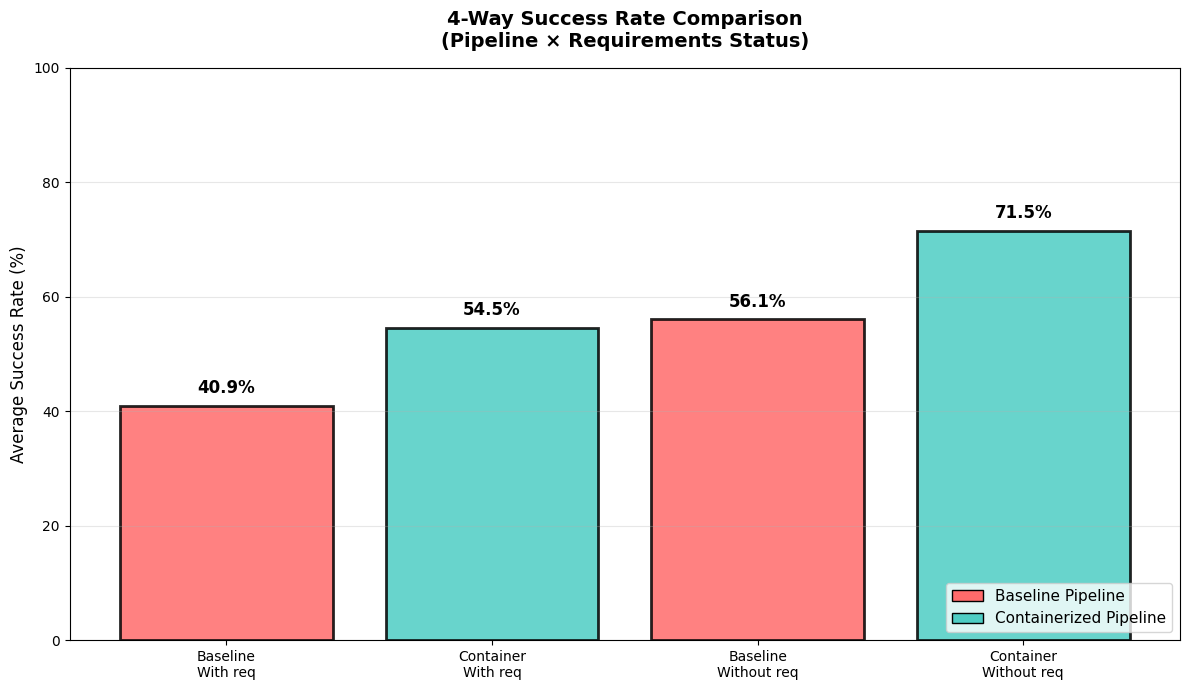

In [27]:


# ============================================================================
# COMBINED 4-WAY COMPARISON of Baseline and Containerized pipeline
# ============================================================================

plt.figure(figsize=(12, 7))

categories = ['Baseline\nWith req', 'Container\nWith req', 
              'Baseline\nWithout req', 'Container\nWithout req']

baseline_has_req = df_has_req['baseline_success_rate'].mean()
baseline_no_req = df_no_req['baseline_success_rate'].mean()
container_has_req = df_has_req['container_success_rate'].mean()
container_no_req = df_no_req['container_success_rate'].mean()
values = [baseline_has_req, container_has_req, baseline_no_req, container_no_req]
colors = ['#FF6B6B', '#4ECDC4', '#FF6B6B', '#4ECDC4']

bars = plt.bar(categories, values, color=colors, alpha=0.85, 
               edgecolor='black', linewidth=2)

# Add value labels
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1.5,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Add connecting lines to show improvement
#plt.plot([0, 1], [baseline_has_req, container_has_req], 'k--', alpha=0.5, linewidth=1.5)
#plt.plot([2, 3], [baseline_no_req, container_no_req], 'k--', alpha=0.5, linewidth=1.5)

plt.ylabel('Average Success Rate (%)', fontsize=12)
plt.title('4-Way Success Rate Comparison\n(Pipeline × Requirements Status)', 
          fontsize=14, fontweight='bold', pad=15)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3, axis='y')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', edgecolor='black', label='Baseline Pipeline'),
    Patch(facecolor='#4ECDC4', edgecolor='black', label='Containerized Pipeline')
]
plt.legend(handles=legend_elements, fontsize=11, loc='lower right')

plt.tight_layout()
plt.savefig('four_way_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# Reproducibility Scores

In [28]:
# ============================================================================
# GET REPRODUCIBILITY SCORES - COMMON REPOSITORIES ONLY
# ============================================================================

query = """
SELECT 
    nrm.reproducibility_score,
    r.repository AS repository_name,
    CASE 
        WHEN r.requirements IS NOT NULL AND r.requirements != '' 
        THEN 'With requirements.txt'
        ELSE 'Without requirements.txt'
    END AS requirements_status
FROM notebook_reproducibility_metrics nrm
JOIN repositories r ON nrm.repository_id = r.id
WHERE nrm.reproducibility_score IS NOT NULL
  
  AND EXISTS (SELECT 1 FROM repository_runs rr WHERE rr.repository_id = r.id)
ORDER BY nrm.reproducibility_score;
"""
df_repro = run_query(query)
print(f"Total notebooks with reproducibility scores: {len(df_repro)}")
print(f"Average reproducibility score: {df_repro['reproducibility_score'].mean():.4f}")
print(f"Fully reproducible (score=1.0): {(df_repro['reproducibility_score'] == 1.0).sum()}")
display(df_repro.describe())

Total notebooks with reproducibility scores: 443
Average reproducibility score: 0.2427
Fully reproducible (score=1.0): 15


,reproducibility_score
count,443.000000
mean,0.242734
std,0.247293
min,0.000000
25%,0.054500
50%,0.167000
75%,0.360500
max,1.000000


# Reproducibility Score Distribution

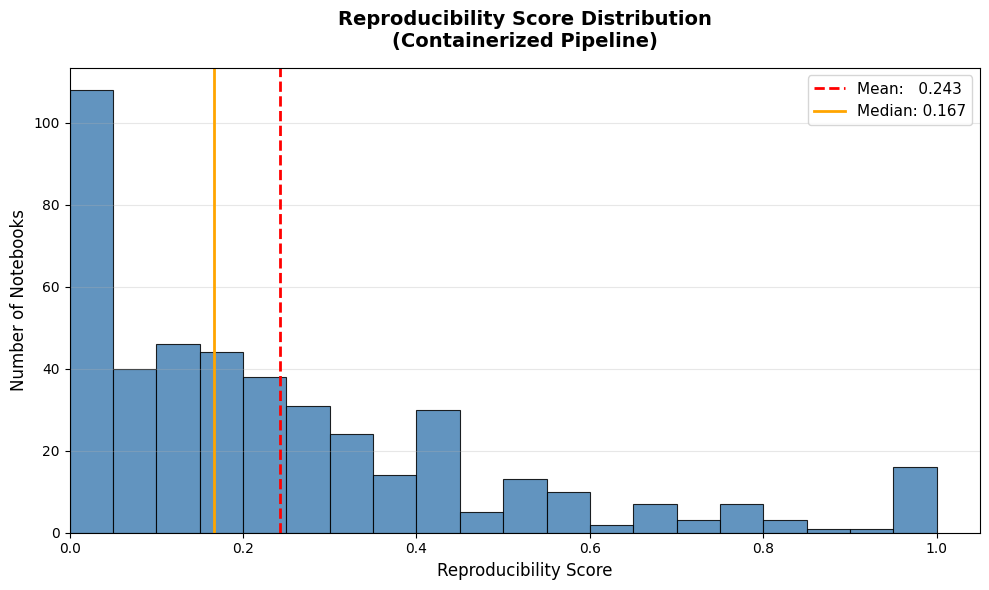

In [29]:
# ============================================================================
# HISTOGRAM OF REPRODUCIBILITY SCORES
# ============================================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df_repro['reproducibility_score'],
    bins=20,
    color='steelblue',
    edgecolor='black',
    linewidth=0.8,
    alpha=0.85
)

# Mean and median lines
mean_score  = df_repro['reproducibility_score'].mean()
median_score = df_repro['reproducibility_score'].median()

plt.axvline(mean_score,   color='red',    linestyle='--', linewidth=2, label=f'Mean:   {mean_score:.3f}')
plt.axvline(median_score, color='orange', linestyle='-',  linewidth=2, label=f'Median: {median_score:.3f}')

plt.title('Reproducibility Score Distribution\n(Containerized Pipeline)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Reproducibility Score', fontsize=12)
plt.ylabel('Number of Notebooks',   fontsize=12)
plt.xlim(0, 1.05)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('reproducibility_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# Reproducibility Score by Category

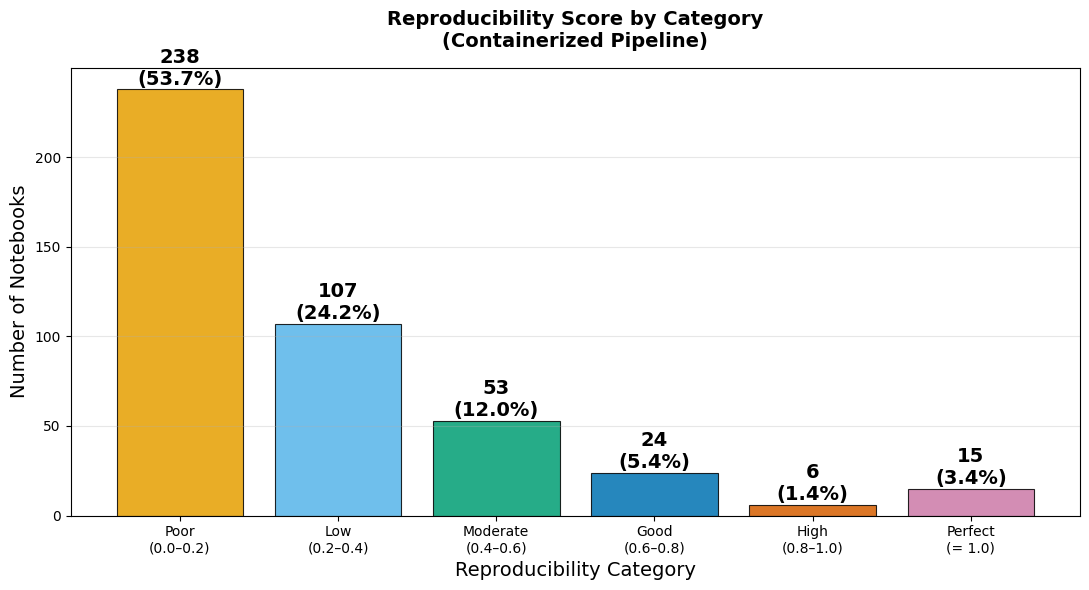

In [30]:
# ============================================================================
# REPRODUCIBILITY SCORE CATEGORIES - BAR CHART
# ============================================================================

# Categorize scores
bins_labels = ['Poor\n(0.0–0.2)', 'Low\n(0.2–0.4)', 'Moderate\n(0.4–0.6)', 
               'Good\n(0.6–0.8)', 'High\n(0.8–1.0)', 'Perfect\n(= 1.0)']

counts = [
    ((df_repro['reproducibility_score'] >= 0.0) & (df_repro['reproducibility_score'] <  0.2)).sum(),
    ((df_repro['reproducibility_score'] >= 0.2) & (df_repro['reproducibility_score'] <  0.4)).sum(),
    ((df_repro['reproducibility_score'] >= 0.4) & (df_repro['reproducibility_score'] <  0.6)).sum(),
    ((df_repro['reproducibility_score'] >= 0.6) & (df_repro['reproducibility_score'] <  0.8)).sum(),
    ((df_repro['reproducibility_score'] >= 0.8) & (df_repro['reproducibility_score'] <  1.0)).sum(),
    ( df_repro['reproducibility_score'] == 1.0).sum(),
]
#colors = ['#d32f2f', '#f57c00', '#fbc02d', '#388e3c', '#1976d2', '#6a1b9a']
colors = [
    '#E69F00', # Orange
    '#56B4E9', # Sky Blue
    '#009E73', # Bluish Green
    '#0072B2', # Blue
    '#D55E00', # Vermillion
    '#CC79A7'  # Reddish Purple
]

plt.figure(figsize=(11, 6))

bars = plt.bar(bins_labels, counts, color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)

# Add count and percentage labels on bars
total = len(df_repro)
for bar, count in zip(bars, counts):
    pct = count / total * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{count}\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=14, fontweight='bold'
    )

plt.title('Reproducibility Score by Category\n(Containerized Pipeline)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Reproducibility Category', fontsize=14)
plt.ylabel('Number of Notebooks',      fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('reproducibility_categories.png', dpi=150, bbox_inches='tight')
plt.show()

# Reproducibility scores by requirements

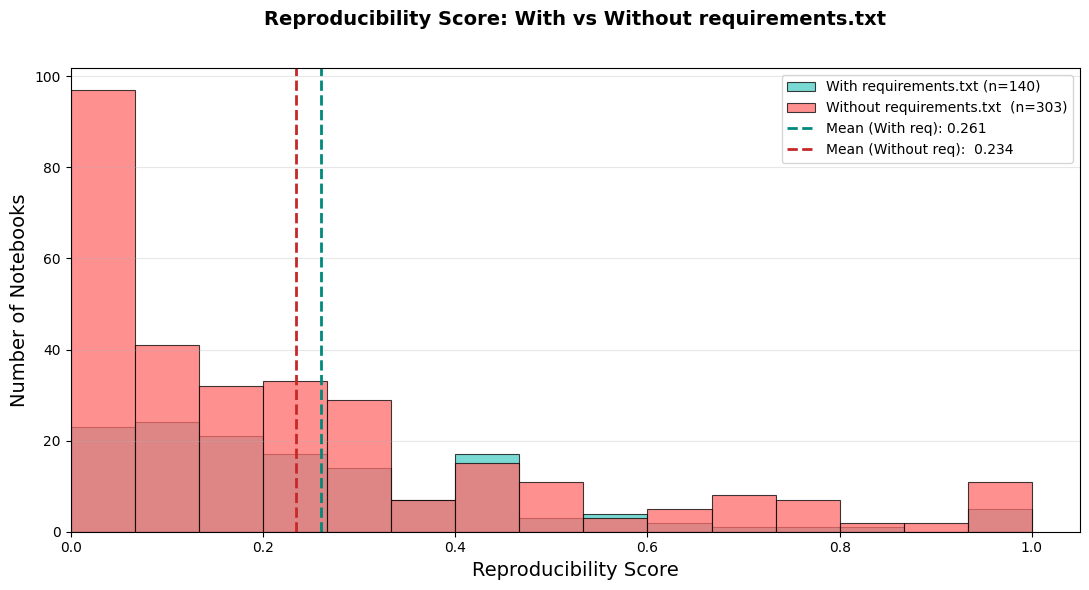

In [31]:
# ============================================================================
# With requirements VS Without requirements - REPRODUCIBILITY SCORES
# ============================================================================

df_has_req = df_repro[df_repro['requirements_status'] == 'With requirements.txt']['reproducibility_score']
df_no_req  = df_repro[df_repro['requirements_status'] == 'Without requirements.txt']['reproducibility_score']

plt.figure(figsize=(11, 6))

plt.hist(df_has_req, bins=15, color='#4ECDC4', edgecolor='black',
         linewidth=0.8, alpha=0.75, label=f'With requirements.txt (n={len(df_has_req)})')
plt.hist(df_no_req,  bins=15, color='#FF6B6B', edgecolor='black',
         linewidth=0.8, alpha=0.75, label=f'Without requirements.txt  (n={len(df_no_req)})')

plt.axvline(df_has_req.mean(), color='#00897B', linestyle='--', linewidth=2,
            label=f'Mean (With req): {df_has_req.mean():.3f}')
plt.axvline(df_no_req.mean(),  color='#C62828', linestyle='--', linewidth=2,
            label=f'Mean (Without req):  {df_no_req.mean():.3f}')

plt.title('Reproducibility Score: With vs Without requirements.txt\n',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Reproducibility Score', fontsize=14)
plt.ylabel('Number of Notebooks',   fontsize=14)
plt.xlim(0, 1.05)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('reproducibility_by_requirements.png', dpi=150, bbox_inches='tight')
plt.show()

# 

In [32]:

print("=" * 80)
print("FAIR ERROR COMPARISON: BASELINE VS CONTAINERIZED")
print("=" * 80)

# ============================================================================
# 1. GET COMPLETE ERROR PICTURE - INCLUDING 85 EXCLUDED NOTEBOOKS
# ============================================================================

print("\n" + "=" * 80)
print("1. COMPLETE ERROR TYPES COMPARISON")
print("=" * 80)

# Get baseline errors for notebooks that were executed
query_baseline_executed = """
SELECT 
    'Baseline Pipeline' AS pipeline,
    CASE 
        WHEN e.reason LIKE '%:%' THEN TRIM(SUBSTR(e.reason, 1, INSTR(e.reason, ':') - 1))
        ELSE COALESCE(e.reason, 'Unknown')
    END AS error_type,
    COUNT(*) AS error_count,
    COUNT(DISTINCT e.repository_id) AS affected_repositories,
    COUNT(DISTINCT e.notebook_id) AS affected_notebooks
FROM executions e
WHERE e.repository_id IN (
    SELECT DISTINCT r.id FROM repositories r
    WHERE EXISTS (SELECT 1 FROM repository_runs rr WHERE rr.repository_id = r.id)
)
AND EXISTS (
    SELECT 1 FROM notebook_executions ne
    WHERE ne.repository_id = e.repository_id
      AND ne.notebook_id = e.notebook_id
)
AND (e.reason IS NOT NULL AND e.reason != '')
GROUP BY e.reason
ORDER BY error_count DESC;
"""

df_baseline_executed = run_query(query_baseline_executed)
df_baseline_executed



FAIR ERROR COMPARISON: BASELINE VS CONTAINERIZED

1. COMPLETE ERROR TYPES COMPARISON


,pipeline,error_type,error_count,affected_repositories,affected_notebooks
0,Baseline Pipeline,<Install Dependency Error>,121,24,121
1,Baseline Pipeline,ModuleNotFoundError,80,23,80
2,Baseline Pipeline,FileNotFoundError,26,16,26
3,Baseline Pipeline,<Skipping notebook>,23,12,23
4,Baseline Pipeline,ImportError,7,1,7
5,Baseline Pipeline,TypeError,5,2,5
6,Baseline Pipeline,ImportError,5,4,5
7,Baseline Pipeline,SyntaxError,4,4,4
8,Baseline Pipeline,NameError,4,4,4
9,Baseline Pipeline,AttributeError,2,2,2


In [33]:

# Get count of excluded notebooks (dependency errors)
query_excluded_count = """
SELECT 
    COUNT(*) AS notebooks_excluded
FROM notebook_executions ne
WHERE ne.repository_id IN (
    SELECT DISTINCT r.id FROM repositories r
    WHERE EXISTS (SELECT 1 FROM repository_runs rr WHERE rr.repository_id = r.id)
)
AND NOT EXISTS (
    SELECT 1 FROM executions e
    WHERE e.repository_id = ne.repository_id
      AND e.notebook_id = ne.notebook_id
);
"""

df_excluded = run_query(query_excluded_count)
notebooks_excluded = df_excluded['notebooks_excluded'].iloc[0]
notebooks_excluded

np.int64(122)

In [34]:

# Combine existing dependency errors with excluded notebooks
# Check if '<Install Dependency Error>' already exists in baseline
install_dep_error_row = df_baseline_executed[
    df_baseline_executed['error_type'] == '<Install Dependency Error>'
]

if len(install_dep_error_row) > 0:
    # Update the count to include excluded notebooks
    existing_count = install_dep_error_row['error_count'].iloc[0]
    df_baseline_executed.loc[
        df_baseline_executed['error_type'] == '<Install Dependency Error>', 
        'error_count'
    ] = existing_count + notebooks_excluded
    df_baseline_complete = df_baseline_executed.copy()
else:
    # Add new row for dependency errors
    dependency_error_row = pd.DataFrame({
        'pipeline': ['Baseline Pipeline'],
        'error_type': ['<Install Dependency Error>'],
        'error_count': [notebooks_excluded],
        'affected_repositories': [0]
    })
    df_baseline_complete = pd.concat([df_baseline_executed, dependency_error_row], ignore_index=True)

df_baseline_complete = df_baseline_complete.sort_values('error_count', ascending=False)

# Add percentage
total_baseline_errors = df_baseline_complete['error_count'].sum()
df_baseline_complete['percentage'] = round(100.0 * df_baseline_complete['error_count'] / total_baseline_errors, 2)

print(f"\nBASELINE PIPELINE - ERROR TYPES ONLY (Excluding Success):")
print(f"  - Total errors: {total_baseline_errors}")
print(f"  - Including {notebooks_excluded} notebooks excluded from baseline")
display(df_baseline_complete)



BASELINE PIPELINE - ERROR TYPES ONLY (Excluding Success):
  - Total errors: 407
  - Including 122 notebooks excluded from baseline


,pipeline,error_type,error_count,affected_repositories,affected_notebooks,percentage
0,Baseline Pipeline,<Install Dependency Error>,243,24,121,59.71
1,Baseline Pipeline,ModuleNotFoundError,80,23,80,19.66
2,Baseline Pipeline,FileNotFoundError,26,16,26,6.39
3,Baseline Pipeline,<Skipping notebook>,23,12,23,5.65
4,Baseline Pipeline,ImportError,7,1,7,1.72
5,Baseline Pipeline,TypeError,5,2,5,1.23
6,Baseline Pipeline,ImportError,5,4,5,1.23
7,Baseline Pipeline,SyntaxError,4,4,4,0.98
8,Baseline Pipeline,NameError,4,4,4,0.98
9,Baseline Pipeline,AttributeError,2,2,2,0.49


In [35]:

# Get containerized errors
query_containerized = """
SELECT 
    'Containerized Pipeline' AS pipeline, 
    COALESCE(ne.error_type, 'Unknown') AS error_type,
    COUNT(*) AS error_count,
    COUNT(DISTINCT ne.repository_id) AS affected_repositories
FROM notebook_executions ne
WHERE ne.repository_id IN (
    SELECT DISTINCT r.id FROM repositories r
    WHERE EXISTS (SELECT 1 FROM repository_runs rr WHERE rr.repository_id = r.id)
)
AND (ne.error_type IS NOT NULL AND ne.error_type != '')
GROUP BY ne.error_category, ne.error_type
ORDER BY error_count DESC;
"""

df_containerized = run_query(query_containerized)
total_containerized = df_containerized['error_count'].sum()
df_containerized['percentage'] = round(100.0 * df_containerized['error_count'] / total_containerized, 2)

print(f"\nCONTAINERIZED PIPELINE - ERROR PICTURE :")
display(df_containerized.head(15))



CONTAINERIZED PIPELINE - ERROR PICTURE :


,pipeline,error_type,error_count,affected_repositories,percentage
0,Containerized Pipeline,ModuleNotFoundError,172,47,44.79
1,Containerized Pipeline,FileNotFoundError,93,29,24.22
2,Containerized Pipeline,ImportError,42,17,10.94
3,Containerized Pipeline,ValueError,15,8,3.91
4,Containerized Pipeline,NameError,12,4,3.12
5,Containerized Pipeline,AttributeError,9,6,2.34
6,Containerized Pipeline,SyntaxError,6,3,1.56
7,Containerized Pipeline,TypeError,4,4,1.04
8,Containerized Pipeline,KeyError,4,3,1.04
9,Containerized Pipeline,IndexError,4,1,1.04


In [36]:
query_containerized = """
SELECT 
    'Containerized Pipeline' AS pipeline, 
    COALESCE(ne.error_type, 'Unknown') AS error_type,
    COUNT(*) AS error_count,
    COUNT(DISTINCT ne.repository_id) AS affected_repositories,
    COUNT(DISTINCT ne.notebook_id) AS affected_notebooks
FROM notebook_executions ne
WHERE ne.repository_id IN (
    SELECT DISTINCT r.id FROM repositories r
    WHERE EXISTS (SELECT 1 FROM repository_runs rr WHERE rr.repository_id = r.id)
)
AND (ne.error_type IS NOT NULL AND ne.error_type != '')
GROUP BY ne.error_type
ORDER BY error_count DESC;
"""

df_containerized = run_query(query_containerized)
df_containerized

,pipeline,error_type,error_count,affected_repositories,affected_notebooks
0,Containerized Pipeline,ModuleNotFoundError,172,47,172
1,Containerized Pipeline,FileNotFoundError,93,29,93
2,Containerized Pipeline,ImportError,42,17,42
3,Containerized Pipeline,ValueError,15,8,15
4,Containerized Pipeline,NameError,12,4,12
5,Containerized Pipeline,AttributeError,9,6,9
6,Containerized Pipeline,SyntaxError,6,3,6
7,Containerized Pipeline,TypeError,4,4,4
8,Containerized Pipeline,RuntimeError,4,4,4
9,Containerized Pipeline,KeyError,4,3,4


In [37]:
# Get all unique error types from both pipelines
all_errors = set(df_baseline_complete['error_type'].tolist() + 
                 df_containerized['error_type'].tolist())

# Create a combined dataframe for consistent ordering
error_comparison = []
for error in all_errors:
    baseline_count = df_baseline_complete[df_baseline_complete['error_type'] == error]['error_count'].sum()
    container_count = df_containerized[df_containerized['error_type'] == error]['error_count'].sum()
    total_count = baseline_count + container_count
    
    error_comparison.append({
        'error_type': error,
        'baseline_count': baseline_count,
        'container_count': container_count,
        'total_count': total_count
    })

df_comparison = pd.DataFrame(error_comparison)
df_comparison = df_comparison.sort_values('total_count', ascending=False).head(12)


In [38]:
# Prepare data for plotting
error_labels = [err[:50] + '...' if len(err) > 50 else err 
                for err in df_comparison['error_type']]
baseline_counts = df_comparison['baseline_count'].values
container_counts = df_comparison['container_count'].values

# Color for Install Dependency Error
colors_baseline = ['#C62828' if err == '<Install Dependency Error>' else '#FF6B6B' 
                   for err in df_comparison['error_type']]
colors_container = ['#008080' if err == '<Install Dependency Error>' else '#4ECDC4' 
                    for err in df_comparison['error_type']]



/tmp/ipykernel_2466658/4001702931.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(int(x))}' for x in x_labels])


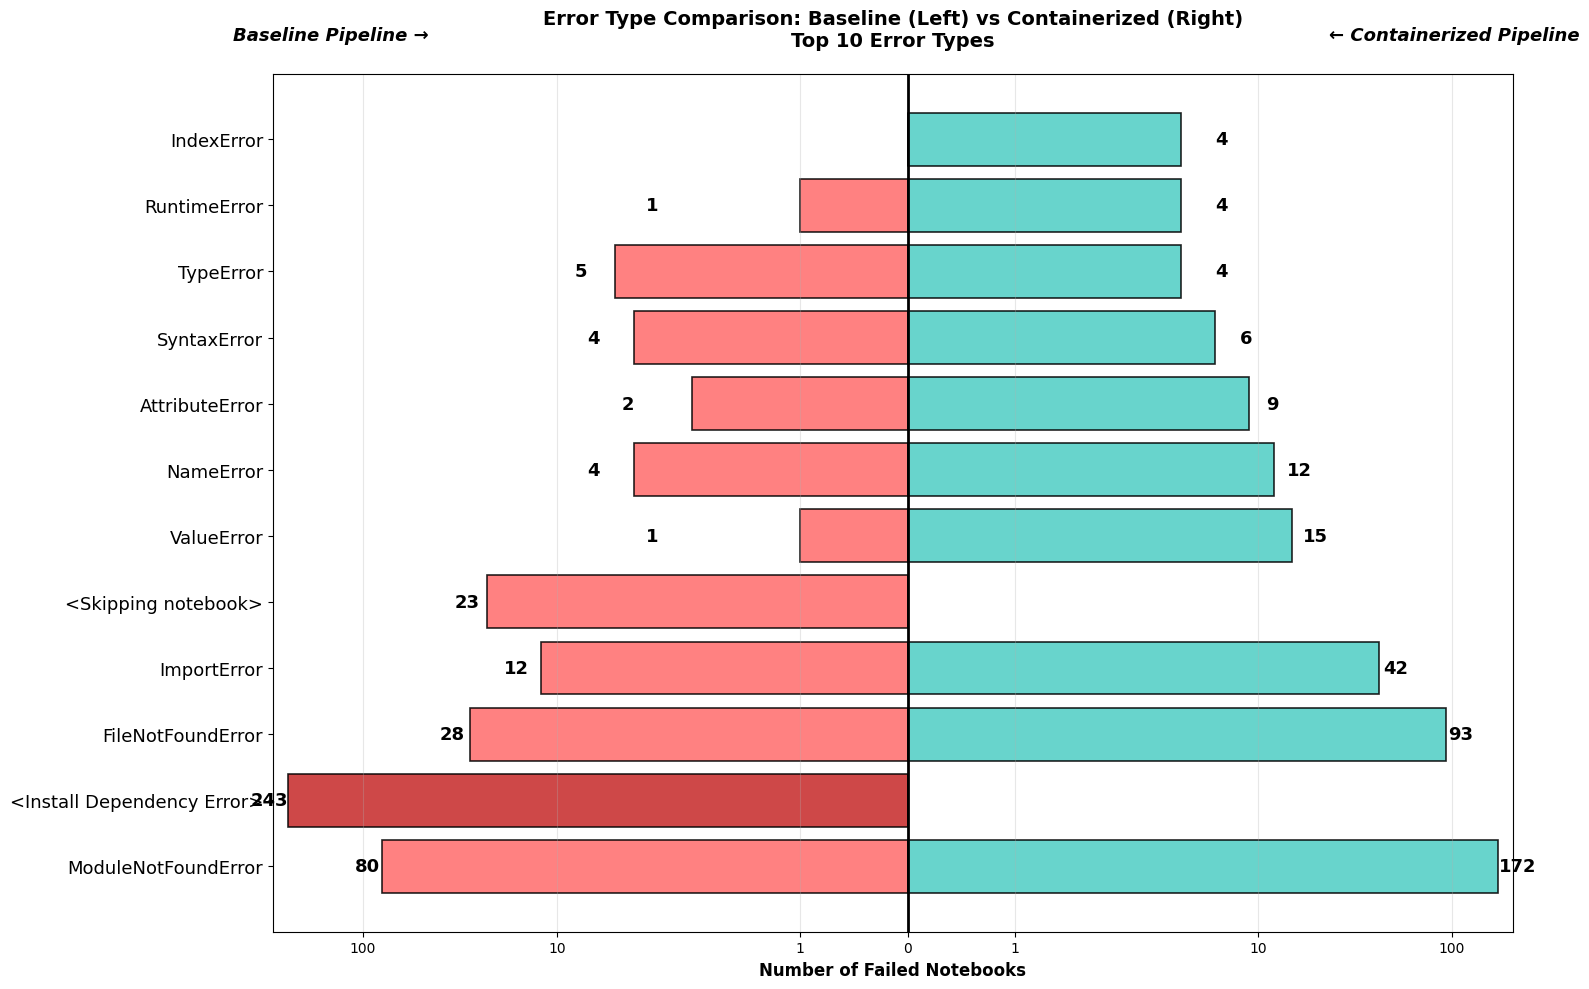

In [39]:
# ============================================================================
# MIRRORED HORIZONTAL BAR CHART (BUTTERFLY/PYRAMID STYLE)
# ============================================================================

fig, ax = plt.subplots(figsize=(16, 10))

# Use same error ordering
y_pos = np.arange(len(df_comparison))

# Plot baseline on left (negative x-axis)
bars_baseline = ax.barh(y_pos, -baseline_counts, 
                        color=colors_baseline, alpha=0.85, 
                        edgecolor='black', linewidth=1.2,
                        label='Baseline')

# Plot containerized on right (positive x-axis)
bars_container = ax.barh(y_pos, container_counts, 
                         color=colors_container, alpha=0.85,
                         edgecolor='black', linewidth=1.2,
                         label='Containerized')

# Add count labels
for i, (base_count, cont_count) in enumerate(zip(baseline_counts, container_counts)):
    if base_count > 0:
        ax.text(-base_count - 2, i, f'{int(base_count)}',
               ha='right', va='center', fontsize=13, fontweight='bold')
    if cont_count > 0:
        ax.text(cont_count + 2, i, f'{int(cont_count)}',
               ha='left', va='center', fontsize=13, fontweight='bold')

# Set labels and formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(error_labels, fontsize=13)
ax.set_xlabel('Number of Failed Notebooks', fontsize=12, fontweight='bold')
ax.set_title('Error Type Comparison: Baseline (Left) vs Containerized (Right)\nTop 10 Error Types', 
             fontsize=14, fontweight='bold', pad=20)

# Use log scale on x-axis
ax.set_xscale('symlog')  # Symmetric log scale (handles negative values)
ax.axvline(x=0, color='black', linewidth=2)
ax.grid(True, alpha=0.3, axis='x')

# Format x-axis labels to show absolute values
ax.set_xlim(-max(baseline_counts) * 1.2, max(container_counts) * 1.2)
x_labels = ax.get_xticks()
ax.set_xticklabels([f'{abs(int(x))}' for x in x_labels])

# Add pipeline labels
ax.text(-max(baseline_counts) * 0.6, len(df_comparison) + 0.5, 
        'Baseline Pipeline →',
        ha='center', fontsize=13, fontweight='bold', style='italic')
ax.text(max(container_counts) * 0.6, len(df_comparison) + 0.5, 
        '← Containerized Pipeline',
        ha='center', fontsize=13, fontweight='bold', style='italic')

plt.tight_layout()
plt.savefig('error_comparison_mirrored.png', dpi=150, bbox_inches='tight')
plt.show()
